# Linear Regression

- Implementing linear Regression on cleaned data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [18]:
df = pd.read_csv('./cleaned_property_data.csv')
df.shape

(10000, 38)

In [19]:
df.columns

Index(['Property Age', 'Carpet Area (sq.ft.)',
       'Super Buildup Rate (per sq.ft.)', 'Built-Up Area (sq.ft.)',
       'Area as per Approved Plan (sq.ft.)', 'Valuation Area (sq.ft.)',
       'Super Built-up Area (sq.ft.)', 'Total Value (INR)', 'No of Car Parks',
       'Value of Car Park (INR)', 'Final Value by Comparison Method (INR)',
       'Last Sale Price (per sq.ft.)', 'Last to Last Sale Price (per sq.ft.)',
       'Last Sale Year', 'Last to Last Sale Year', 'garden', 'gym', 'lift',
       'parking', 'playground', 'swimming_pool', 'garden.1', 'gym.1', 'lift.1',
       'parking.1', 'playground.1', 'swimming_pool.1', 'Address_Area_encoded',
       'Configuration_encoded', 'Condition_encoded', 'Landmark_Airport',
       'Landmark_Hotel', 'Landmark_Mall', 'Landmark_Metro Station',
       'Landmark_Park', 'Landmark_School', 'Trend_Ratio', 'Trend_Score'],
      dtype='object')

In [20]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Results
RMSE: 0.13
R² Score: 0.9802


In [28]:
train_r2 = r2_score(y_train,model.predict(X_train))
print(f"Train R² Score: {train_r2:.4f}")

Train R² Score: 0.9829


### Visualizations

### 1. Regression Fit vs Actual

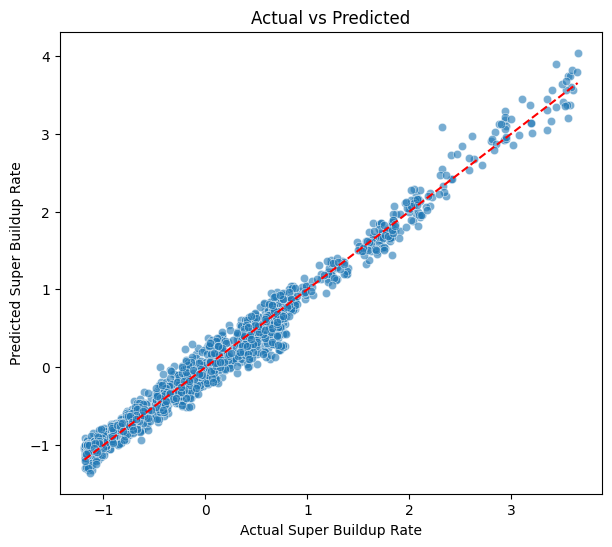

In [23]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted")
plt.show()


### 2. Residual plot

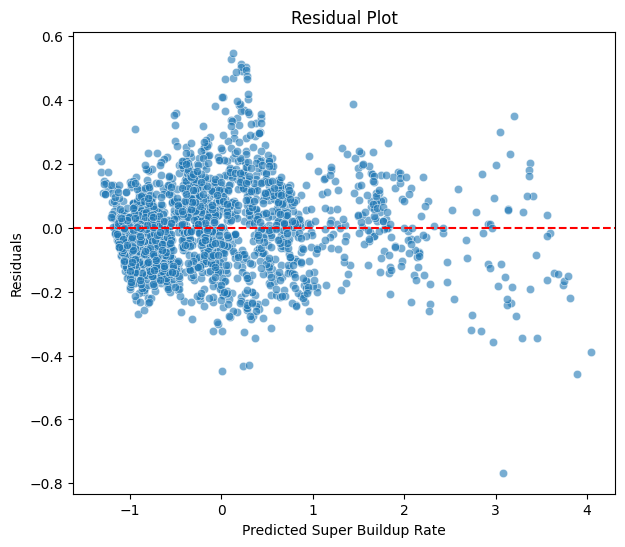

In [24]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Super Buildup Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

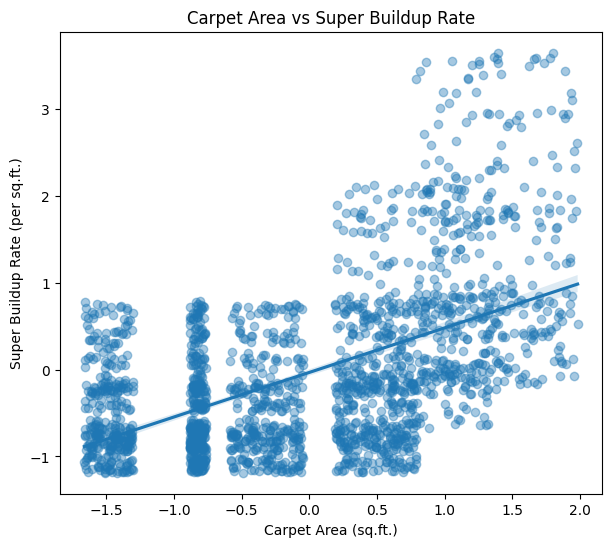

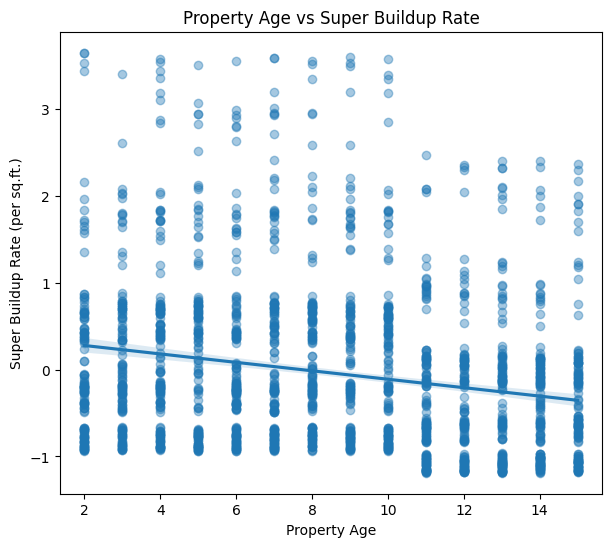

In [25]:
# 3. Feature vs Target (with Carpet Area & Property Age)
plt.figure(figsize=(7,6))
sns.regplot(x=X_test['Carpet Area (sq.ft.)'], y=y_test, scatter_kws={'alpha':0.4})
plt.title("Carpet Area vs Super Buildup Rate")
plt.show()

plt.figure(figsize=(7,6))
sns.regplot(x=X_test['Property Age'], y=y_test, scatter_kws={'alpha':0.4})
plt.title("Property Age vs Super Buildup Rate")
plt.show()

### # 4. Distribution of Errors

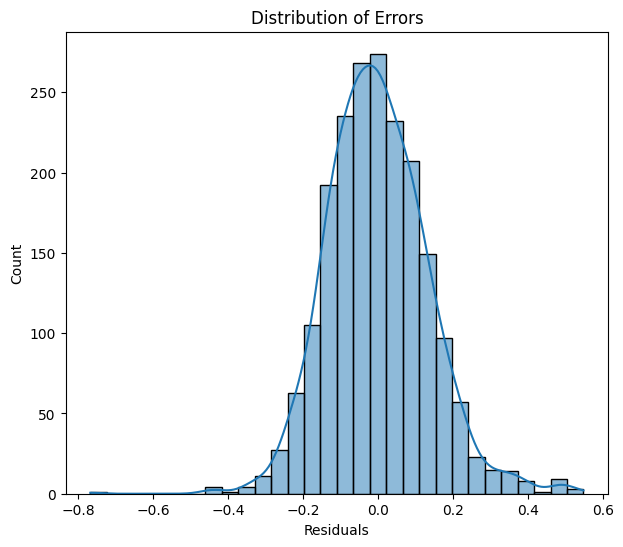

In [26]:
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Errors")
plt.show()

### 5.Model performance

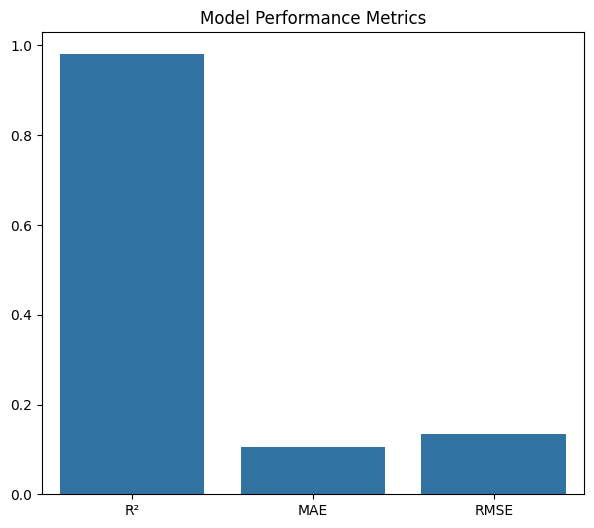

R²: 0.980, MAE: 0.104, RMSE: 0.134


In [27]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(7,6))
sns.barplot(x=["R²", "MAE", "RMSE"], y=[r2, mae, rmse])
plt.title("Model Performance Metrics")
plt.show()

print(f"R²: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")